# N-Plate Model Attitude
---
Last revised by Z. Ellis on 2026 APR 6

## Objectives
This tutorial will demonstrate 

## Imports and Set Up

Here we'll import the necessary libraries and load in the tutorials data folder. Then we define units and frames and load a metakernel to use for time conversions and provide attitude information.

In [1]:
import scarabaeus as scb
from tutorial_data import tutorial_data

import numpy as np
import matplotlib.pyplot as plt

# load tutorial data
data = tutorial_data.load()

## units, frames, kernels
km, hr = scb.Units.get_units(['km', 'hr'])
J2000 = scb.Frame('J2000')

scb.SpiceManager.clear_kernels()    # ensure clean kernel pool
scb.SpiceManager.load_kernel_from_mkfile(data.OREX.mk)
scb.SpiceManager.print_kernels()    # verify C-Kernels for the S/C (sc) and solar arrays (sa)

SCB tutorial data up to date.
                                 Kernels Loaded:
Source:   /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections/tutorials/tutorial_data/kernels/scenario/orex_mk.tm   (META)
Source:   tutorial_data/kernels/scenario/orx_sc_rel_210816_210822_v02.bc   (CK)
Source:   tutorial_data/kernels/scenario/orx_sa_rel_210816_210822_v02.bc   (CK)
Source:   tutorial_data/kernels/scenario/ORX_SCLKSCET_00075.tsc   (TEXT)
Source:   tutorial_data/kernels/lsk/naif0012.tls   (TEXT)
Source:   tutorial_data/kernels/scenario/orx_v14.tf   (TEXT)


# SAY SOMETHING ABOUT THE DIFFERENT KERNELS LOADED

## Define N-Plate Model & Examine CK Panels
Now that we've loaded in the necessary kernels, we'll need to define an N-Plate model to utilize them. Scarabaeus uses a configuration file, which we loaded in with the rest of the tutorial data:

In [2]:
n_model = scb.nPlateModel(data.OREX.nplate)

We'll use `SpiceManager.ckbrief` to look at the SPICE IDs and their matching intervals loaded in with the solar array's attide C-kernel `tutorial_data/kernels/scenario/orx_sa_rel_210816_210822_v02.bc`. Note that we've defined two CK plates in the N-plate configuration JSON, IDs -64017 and -64027 , which are the first and third plate defined in the C-kernel respectively, but the third and fourth plate in the configuration JSON. Since both plates have the same interval, we can just grab the first plate from the brief, corresponding to ID -64207 or Plate 4:

In [3]:
# examine the ID's and intervals within the loaded C-kernel
brief = scb.SpiceManager.ckbrief(data.OREX.ck_sa, disp = True)

# N-plate model defines panels -64017 and -64027 -> use their intervals from C-kernel
plate4 = brief[0]    # coresponds to 4th plate in the configuration file
start, end = plate4['TDB_INTERVAL'][0][0], plate4['TDB_INTERVAL'][0][1]     # both plates have same interval

       Brief orx_sa_rel_210816_210822_v02.bc        
ID: -64027
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64022
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64017
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64012
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)



Now we can query the normal vectors for both plates across the entire interval that they've been defined using `nPlateModel.get_ck_normals`:

In [4]:
# get normals information across time interval
orex_id = -64                                         # need s/c ID for SCLK time
dt = scb.ArrayWUnits(0.5, hr)                         # query every half hour
times = scb.EpochArray.interval(start, end, dt)       # the interval to examine

normals = []
for time in times:
    normals.append(n_model.get_ck_normals(time, orex_id))

## Plot C-Kernel Normal Vectors
With the normal vectors queried from the C-kernel, we can write a function to plot their time history. This figure will let us scroll through each queried epoch and see how the normal vector changes in the body frame of OSIRIS-REx.

> **NOTE:** the magic command `%matplotlib widget` is only placed in this notebook to allow for the figure to be interactive.

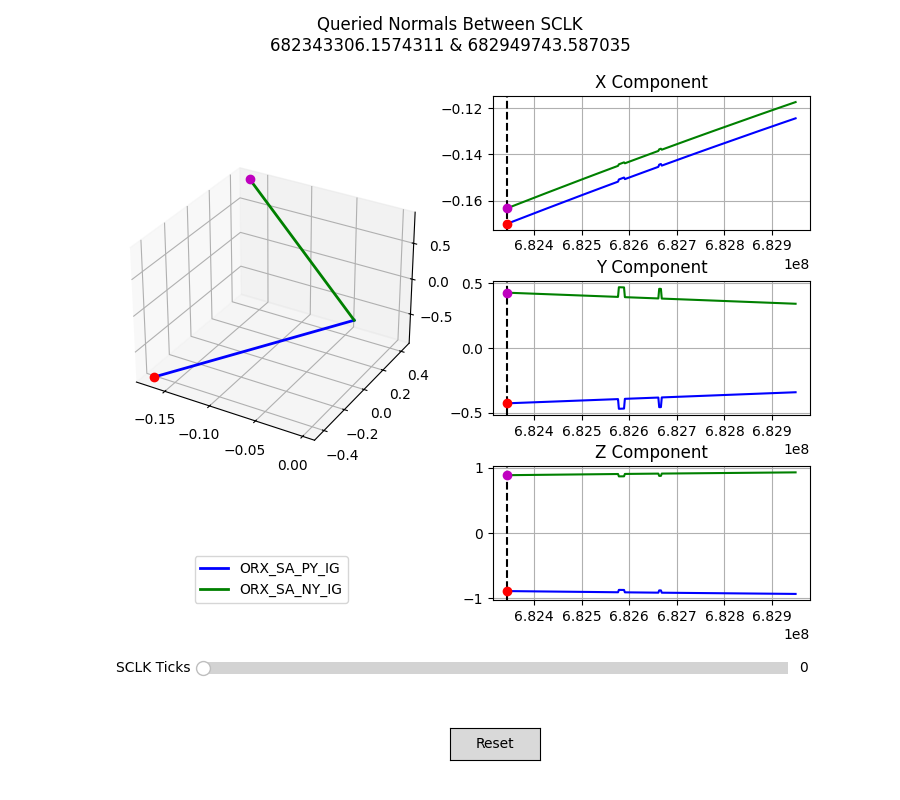

In [5]:
%matplotlib widget
def plot_normals(normals, times):
    from matplotlib.widgets import Button, Slider
    fig = plt.figure(figsize = (9, 8))
    axes = fig.subplot_mosaic(
        [['3d', 'x'],
         ['3d', 'x'],
         ['3d', 'y'],
         ['3d', 'y'],
         ['3d', 'z'],
         ['leg', 'z']],
         per_subplot_kw = {'3d' : {'projection' : '3d'}}
    )
    ax = axes['3d']
    fig.subplots_adjust(bottom = 0.25)

    ## 3d representation
    # first normal
    l1 = ax.plot([0, normals[0][0][0]], [0, normals[0][0][1]], [0, normals[0][0][2]], 
                 'b', lw = 2)
    p1 = ax.plot(normals[0][0][0], normals[0][0][1], normals[0][0][2], 'ro')

    # second normal
    l2 = ax.plot([0, normals[0][1][0]], [0, normals[0][1][1]], [0, normals[0][1][2]], 
                 'g', lw = 2)
    p2 = ax.plot(normals[0][1][0], normals[0][1][1], normals[0][1][2], 'mo')

    ## 2d representation
    # extract components for both normals
    axx, axy, axz = axes['x'], axes['y'], axes['z']
    x1s, x2s, y1s, y2s, z1s, z2s = [], [], [], [], [], []
    for normal in normals:
        frst, scnd = normal[0], normal[1]

        x1s.append(frst[0])
        y1s.append(frst[1])
        z1s.append(frst[2])

        x2s.append(scnd[0])
        y2s.append(scnd[1])
        z2s.append(scnd[2])
    
    # get times just as values
    t_vals   = np.linspace(start.times.values, end.times.values, times.size)

    # plot x component
    axx.plot(t_vals, x1s, 'b')
    axx.plot(t_vals, x2s, 'g')
    marker_x1 = axx.axvline(t_vals[0], ls = '--', c = 'k')
    dot_x1    = axx.plot(t_vals[0], x1s[0], 'ro')
    dot_x2    = axx.plot(t_vals[0], x2s[0], 'mo')
    axx.grid()
    axx.set_title('X Component')

    # plot y component
    axy.plot(t_vals, y1s, 'b')
    axy.plot(t_vals, y2s, 'g')
    marker_y1 = axy.axvline(t_vals[0], ls = '--', c = 'k')
    dot_y1    = axy.plot(t_vals[0], y1s[0], 'ro')
    dot_y2    = axy.plot(t_vals[0], y2s[0], 'mo')
    axy.grid()
    axy.set_title('Y Component')

    # plot z component
    axz.plot(t_vals, z1s, 'b')
    axz.plot(t_vals, z2s, 'g')
    marker_z1 = axz.axvline(t_vals[0], ls = '--', c = 'k')
    dot_z1    = axz.plot(t_vals[0], z1s[0], 'ro')
    dot_z2    = axz.plot(t_vals[0], z2s[0], 'mo')
    axz.grid()
    axz.set_title('Z Component')

    ## formatting
    fig.suptitle(f'Queried Normals Between SCLK\n{t_vals[0]} & {t_vals[-1]}')
    fig.subplots_adjust(hspace = 1.25)

    # place legend in its own empty subplot
    ax_leg = axes['leg']
    ax_leg.set_axis_off()
    ax_leg.plot(0, 0, 'b', lw = 2, label = 'ORX_SA_PY_IG')
    ax_leg.plot(0, 0, 'g', lw = 2, label = 'ORX_SA_NY_IG')
    ax_leg.legend(loc = 'center')

    # define the values to use for snapping
    time_ticks = np.linspace(0, len(t_vals), len(t_vals)+1)
    ax_amp = fig.add_axes([0.225, 0.15, 0.65, 0.03])

    # make time slider
    time_slider = Slider(
        ax_amp, "SCLK Ticks", 0, len(t_vals)-1,
        valinit = 0, valstep = time_ticks,
        color = "green"
    )

    def update(_):
        time = int(time_slider.val)
        ## first normal
        # extract data
        x_pos = normals[time][0][0]
        y_pos = normals[time][0][1]
        z_pos = normals[time][0][2]
        # update plots
        l1[0].set_data_3d([0, x_pos], [0, y_pos], [0, z_pos])
        p1[0].set_data_3d([x_pos, x_pos], [y_pos, y_pos], [z_pos, z_pos])
        marker_x1.set_xdata([t_vals[time], t_vals[time]])
        dot_x1[0].set_xdata([t_vals[time], t_vals[time]])
        dot_x1[0].set_ydata([x1s[time], x1s[time]])
        marker_y1.set_xdata([t_vals[time], t_vals[time]])
        dot_y1[0].set_xdata([t_vals[time], t_vals[time]])
        dot_y1[0].set_ydata([y1s[time], y1s[time]])
        marker_z1.set_xdata([t_vals[time], t_vals[time]])
        dot_z1[0].set_xdata([t_vals[time], t_vals[time]])
        dot_z1[0].set_ydata([z1s[time], z1s[time]])

        ## second normal
        # extract data
        x_pos = normals[time][1][0]
        y_pos = normals[time][1][1]
        z_pos = normals[time][1][2]
        # update plots
        l2[0].set_data_3d([0, x_pos], [0, y_pos], [0, z_pos])
        p2[0].set_data_3d([x_pos, x_pos], [y_pos, y_pos], [z_pos, z_pos])
        dot_x2[0].set_xdata([t_vals[time], t_vals[time]])
        dot_x2[0].set_ydata([x2s[time], x2s[time]])
        dot_y2[0].set_xdata([t_vals[time], t_vals[time]])
        dot_y2[0].set_ydata([y2s[time], y2s[time]])
        dot_z2[0].set_xdata([t_vals[time], t_vals[time]])
        dot_z2[0].set_ydata([z2s[time], z2s[time]])
        
        fig.canvas.draw_idle()

    time_slider.on_changed(update)

    ax_reset = fig.add_axes([0.5, 0.05, 0.1, 0.04])
    button = Button(ax_reset, 'Reset', hovercolor='0.975')

    def reset(event):
        time_slider.reset()
    button.on_clicked(reset)

    plt.show()

plot_normals(normals, times)

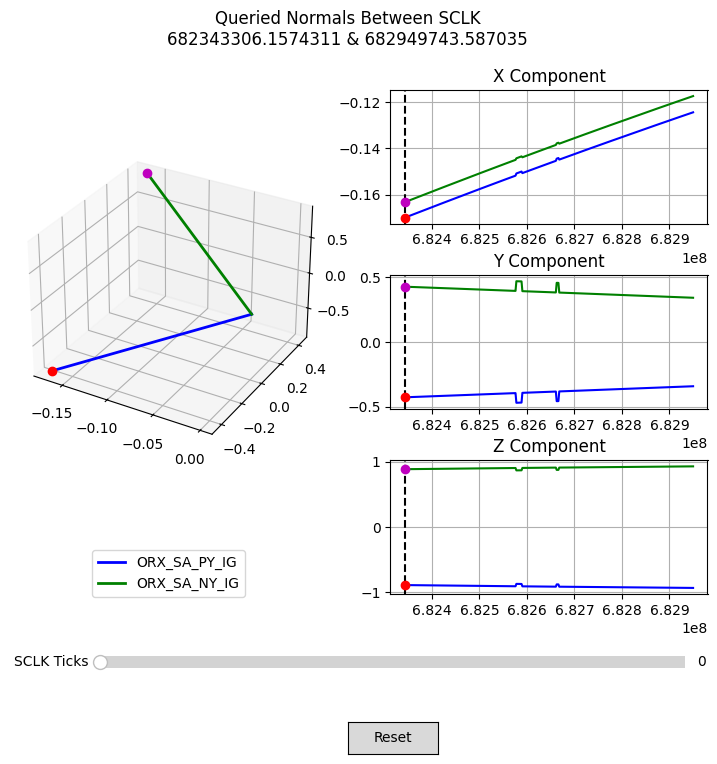

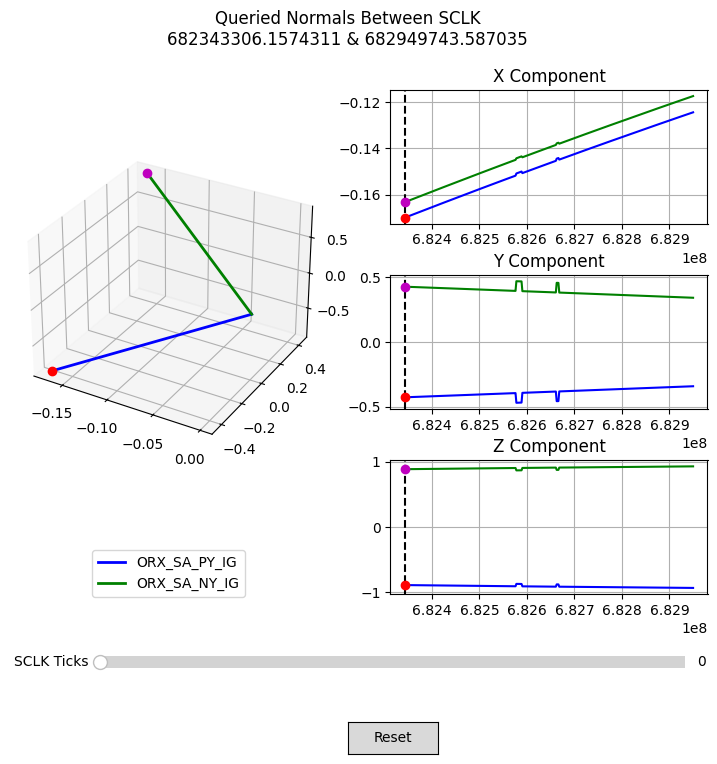

In [6]:
%matplotlib inline
# NOTE: rerun static version of the plot so that it displays for online tutorial 
plot_normals(normals, times)

# Conclusion
DESC